## Importing Libraries

In [1]:
# Import libraries
from pathlib import Path

import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import plotly.express as px
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay) 

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

%matplotlib inline

## Loading, preprocessing and analyzing Mutagenicity data

In [2]:
qspr_data_path = Path.cwd() / "data" / "qspr_mutagenicity_training.csv"

In [3]:
# Load the mutagenicity data
df = pd.read_csv(qspr_data_path)

In [85]:
df

,Unnamed: 0.1,Unnamed: 0,Id,CAS,SMILES,Status,Experimental value,Predicted value,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,0,0,1,100-00-5,O=[N+]([O-])c1ccc(cc1)Cl,Training,1,1,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,1,1,2,100-01-6,O=[N+]([O-])c1ccc(N)cc1,Training,1,1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,2,2,3,100-02-7,O=[N+]([O-])c1ccc(O)cc1,Training,0,1,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,3,3,4,100-11-8,O=[N+]([O-])c1ccc(cc1)CBr,Training,1,0,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,4,4,5,100-12-9,O=[N+]([O-])c1ccc(cc1)CC,Training,0,0,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5759,5759,5759,5767,20395-16-8,O=C1N(C(=O)N(C(=O)N1CC=C)CC2OC2)CC=C,Training,1,0,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,5760,5760,5768,34718-47-3,O=C(C(Br)(Br)Br)Cl,Training,1,1,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,5761,5761,5769,43204-63-3,N(CCBr)CCBr,Training,1,1,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,5762,5762,5770,52583-35-4,N#Cc2cc(cc(c2(N=Nc1ccc(cc1(NC(=O)C))N(CCOC)CCO...,Training,1,1,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5764 entries, 0 to 5763
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0.1         5764 non-null   int64  
 1   Unnamed: 0           5764 non-null   int64  
 2   Id                   5764 non-null   int64  
 3   CAS                  5764 non-null   object 
 4   SMILES               5764 non-null   object 
 5   Status               5764 non-null   object 
 6   Experimental value   5764 non-null   int64  
 7   Predicted value      5764 non-null   object 
 8   NumValenceElectrons  5764 non-null   int64  
 9   qed                  5764 non-null   float64
 10  TPSA                 5764 non-null   float64
 11  MolMR                5764 non-null   float64
 12  BalabanJ             5764 non-null   float64
 13  BertzCT              5764 non-null   float64
 14  MolWt                5764 non-null   float64
 15  MolLogP              5764 non-null   f

In [6]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Id,CAS,SMILES,Status,Experimental value,Predicted value,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,0,0,1,100-00-5,O=[N+]([O-])c1ccc(cc1)Cl,Training,1,1,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.2482
1,1,1,2,100-01-6,O=[N+]([O-])c1ccc(N)cc1,Training,1,1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.1770
2,2,2,3,100-02-7,O=[N+]([O-])c1ccc(O)cc1,Training,0,1,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.3004
3,3,3,4,100-11-8,O=[N+]([O-])c1ccc(cc1)CBr,Training,1,0,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.4897
4,4,4,5,100-12-9,O=[N+]([O-])c1ccc(cc1)CC,Training,0,0,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.1572


In [7]:
mutagenic_data = df[df['Experimental value']==1]
mutagenic_data.info()
mutagenic_data.head()


<class 'pandas.core.frame.DataFrame'>
Index: 3251 entries, 0 to 5763
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0.1         3251 non-null   int64  
 1   Unnamed: 0           3251 non-null   int64  
 2   Id                   3251 non-null   int64  
 3   CAS                  3251 non-null   object 
 4   SMILES               3251 non-null   object 
 5   Status               3251 non-null   object 
 6   Experimental value   3251 non-null   int64  
 7   Predicted value      3251 non-null   object 
 8   NumValenceElectrons  3251 non-null   int64  
 9   qed                  3251 non-null   float64
 10  TPSA                 3251 non-null   float64
 11  MolMR                3251 non-null   float64
 12  BalabanJ             3251 non-null   float64
 13  BertzCT              3251 non-null   float64
 14  MolWt                3251 non-null   float64
 15  MolLogP              3251 non-null   float6

,Unnamed: 0.1,Unnamed: 0,Id,CAS,SMILES,Status,Experimental value,Predicted value,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,0,0,1,100-00-5,O=[N+]([O-])c1ccc(cc1)Cl,Training,1,1,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.2482
1,1,1,2,100-01-6,O=[N+]([O-])c1ccc(N)cc1,Training,1,1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.1770
3,3,3,4,100-11-8,O=[N+]([O-])c1ccc(cc1)CBr,Training,1,0,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.4897
6,6,6,7,100-13-0,O=[N+]([O-])c1ccc(C=C)cc1,Training,1,0,56,0.477660,43.14,43.1874,3.000887,276.648462,149.149,2.2378
7,7,7,8,100-14-1,O=[N+]([O-])c1ccc(cc1)CCl,Training,1,1,58,0.389482,43.14,42.6534,2.913802,257.648013,171.583,2.3336


In [8]:
# Identify the non-predicted molecules from VEGA model
df[df['Predicted value'] == 'Non Predicted']

,Unnamed: 0.1,Unnamed: 0,Id,CAS,SMILES,Status,Experimental value,Predicted value,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
1844,1844,1844,1846,16709-86-7,C=C[Si](C)(C)CCl,Training,0,Non Predicted,42,0.401439,0.00,38.399,3.575471,68.480406,134.682,2.19800
2194,2194,2194,2197,2179-59-1,C=CCSSCCC,Training,0,Non Predicted,48,0.333839,0.00,45.404,2.616293,52.490225,148.296,2.96380
4118,4118,4118,4125,624-92-0,CSSC,Training,0,Non Predicted,26,0.452840,0.00,27.030,1.974745,6.000000,94.204,1.62740
4180,4180,4180,4187,6317-18-6,N#CSCSC#N,Training,0,Non Predicted,36,0.321595,47.58,31.275,2.768386,95.083765,130.197,1.37246
5633,5633,5633,5641,7783-54-2,FN(F)F,Training,1,Non Predicted,26,0.383980,3.24,5.163,2.323790,8.000000,71.001,0.94190
5655,5655,5655,5663,676-83-5,CP(Cl)Cl,Training,1,Non Predicted,26,0.426990,0.00,24.550,2.323790,10.754888,116.915,2.40570


In [9]:
# Remove the non-predicted molecules from VEGA model
non_predicted_index = df.loc[df['Predicted value'] == 'Non Predicted'].index
df.drop(non_predicted_index, inplace=True)

In [56]:
# Remove the columns that are not needed for the model
X = df.drop(['Unnamed: 0.1', 'Unnamed: 0', 'Id','CAS','SMILES','Experimental value', 'Status','Predicted value'],axis=1)

In [57]:
X

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
0,52,0.463602,43.14,38.1064,3.003401,244.429658,157.556,2.24820
1,52,0.359544,69.16,37.5088,3.003401,242.429658,138.126,1.17700
2,52,0.470728,63.37,34.7612,3.003401,241.674771,139.110,1.30040
3,58,0.432586,43.14,45.7274,2.913802,257.648013,216.034,2.48970
4,58,0.479785,43.14,42.4744,2.913802,253.299498,151.165,2.15720
...,...,...,...,...,...,...,...,...
5759,102,0.485090,78.53,69.3560,2.668492,627.435628,265.269,-1.05750
5760,42,0.495987,17.07,40.3720,3.791118,85.425922,315.186,2.59030
5761,44,0.568556,12.03,40.4577,2.447473,28.870765,230.931,1.36580
5762,184,0.264581,185.59,125.3525,2.552977,1169.342047,485.457,3.84768


## Correlation Matrix

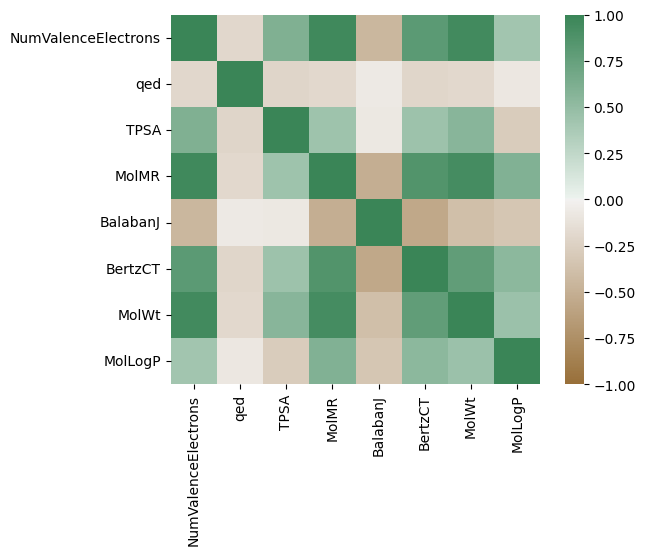

In [58]:
corr_mol_disc = X.corr()
axis_corr = sns.heatmap(
    corr_mol_disc,
    vmin= -1, 
    vmax = 1,
    center=0,
    cmap = sns.diverging_palette(50,500, as_cmap=True),
    square=True
)

plt.show()

In [59]:
corr_mol_disc

,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,MolWt,MolLogP
NumValenceElectrons,1.000000,-0.200737,0.604191,0.961790,-0.446378,0.805320,0.948927,0.417977
qed,-0.200737,1.000000,-0.216025,-0.188647,-0.063150,-0.209378,-0.194112,-0.083097
TPSA,0.604191,-0.216025,1.000000,0.440383,-0.072740,0.449473,0.558071,-0.282042
MolMR,0.961790,-0.188647,0.440383,1.000000,-0.514867,0.865258,0.935005,0.595593
BalabanJ,-0.446378,-0.063150,-0.072740,-0.514867,1.000000,-0.559712,-0.382986,-0.334971
BertzCT,0.805320,-0.209378,0.449473,0.865258,-0.559712,1.000000,0.778555,0.534236
MolWt,0.948927,-0.194112,0.558071,0.935005,-0.382986,0.778555,1.000000,0.459762
MolLogP,0.417977,-0.083097,-0.282042,0.595593,-0.334971,0.534236,0.459762,1.000000


## Removing correlated descriptors [NumValenceElectrons, MolMR]

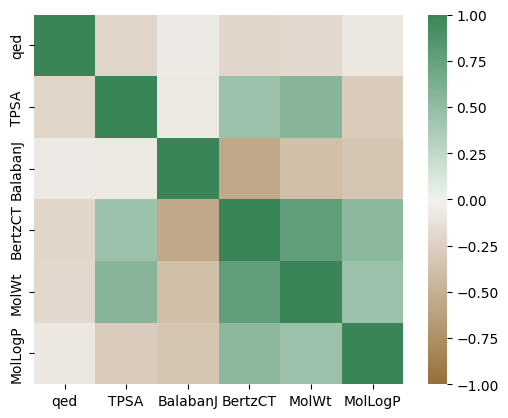

In [60]:
X = X.drop(['NumValenceElectrons', 'MolMR' ], axis = 1)

corr_mol_disc = X.corr()
axis_corr = sns.heatmap(
    corr_mol_disc,
    vmin= -1, 
    vmax = 1,
    center=0,
    cmap = sns.diverging_palette(50,500, as_cmap=True),
    square=True
)

plt.show()

In [61]:
# Nnumber of molecules with QED score less than 0.5
print((df['qed'] < 0.5).sum())
# Molecule with the maximum molecular weight
max_mw_mol = df[df['MolWt'] == df['MolWt'].max()][['SMILES','MolWt','CAS']]
print(max_mw_mol)
# Print the mean number of valence electrons
print(df['NumValenceElectrons'].mean())

2672
                                                 SMILES     MolWt         CAS
5220  O=C(NCC(O)CO)c1c(c(C(=O)NCC(O)CO)c(c(c1I)N(C(=...  1550.188  92339-11-2
87.03108718304966


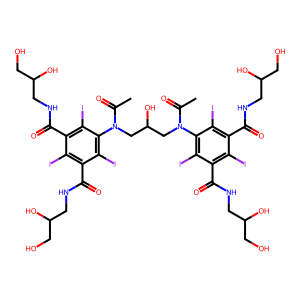

In [62]:
# Plot the molecule with the maximum molecular weight
from rdkit import Chem
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles(max_mw_mol.SMILES.values[0])
Draw.MolToImage(mol)

### Checking class imbalance between two classes

In [99]:
# Print the percentage of mutagenic and non-mutagenic molecules
y_true = df['Experimental value'].to_numpy()
y_vega = df['Predicted value'].to_numpy(dtype=int)
perc_mutegenic = y.sum()/len(y)*100
perc_non_mutegenic = (1-y.sum()/len(y))*100
print(f"Percentage of mutagenic molecules: {perc_mutegenic:.2f}%")
print(f"Percentage of non-mutagenic molecules: {perc_non_mutegenic:.2f}%")

Percentage of mutagenic molecules: 56.43%
Percentage of non-mutagenic molecules: 43.57%


## Chemical similarity space visualization (PCA)

In [113]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [100]:
vega_correct = (y_true == y_vega)

In [ ]:
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print('Explained Variance Ratio for Selected components', pca.explained_variance_ratio_)

Explained Variance Ratio for Selected components [0.45715269 0.23296494 0.16156485]


In [130]:
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

### PCA: Global chemical space structure

In [109]:
df_pca_plot = pd.DataFrame({
    "PCA1" : X_pca[:,0],
    "PCA2": X_pca[:,1],
    "PCA3": X_pca[:,2],
    "Class": y_true,
    "vega_correct": vega_correct
})

fig = px.scatter_3d(
    df_pca_plot,
    x = "PCA1",
    y = "PCA2",
    z = "PCA3",
    color = "Class",
    opacity=0.7,
    title = "Interactive 3D PCA Chem Descriptor Space",
    )


fig.update_layout(
    width=800,
    height=800
)

fig.show()

### t-SNE: Local chemical similarity

In [131]:
df_tsne_plot = pd.DataFrame({
    "tSNE1" : X_tsne[:,0],
    "tSNE2": X_tsne[:,1],
    "Class": y_true,
})

fig = px.scatter(
    df_tsne_plot,
    x = "tSNE1",
    y = "tSNE2",
    color = "Class",
    opacity=0.7,
    title = "Interactive 2D t-SNE Chem Descriptor Space",
    )


fig.update_layout(
    width=800,
    height=800
)

fig.show()

### PCA visualization with VEGA model errors highlighted

In [112]:
# VEGA correct points
fig = px.scatter_3d(
    df_pca_plot,
    x = "PCA1",
    y = "PCA2",
    z = "PCA3",
    color = "vega_correct",
    opacity=0.7,
    title = "VEGA Model Failures in PCA Chemical Space",
    labels={"VEGA Correct", "VEGA Failures"}
    )

fig.update_layout(
    width=800,
    height=800
)

fig.show()

### Train and Test split 80/20

In [132]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.2, random_state=42)

In [133]:
# Print the number of points in the training and test sets
print('Training points: ', len(y_train))
print('Test points: ', len(y_test))

Training points:  4606
Test points:  1152


### Validating class imbalance in splits

In [134]:
# Training set mutagenic and non-mutagenic percentages
perc_mutegenic_train = y_train.sum()/len(y_train)*100
perc_non_mutegenic_train = (1-y_train.sum()/len(y_train))*100
print(f"Percentage of mutagenic molecules in training set: {perc_mutegenic_train:.2f}%")
print(f"Percentage of non-mutagenic molecules in training set: {perc_non_mutegenic_train:.2f}%")

# Test set mutagenic and non-mutagenic percentages
perc_mutegenic_test = y_test.sum()/len(y_test)*100
perc_non_mutegenic_test = (1-y_test.sum()/len(y_test))*100
print(f"Percentage of mutagenic molecules in test set: {perc_mutegenic_test:.2f}%")
print(f"Percentage of non-mutagenic molecules in test set: {perc_non_mutegenic_test:.2f}%")

Percentage of mutagenic molecules in training set: 56.49%
Percentage of non-mutagenic molecules in training set: 43.51%
Percentage of mutagenic molecules in test set: 56.16%
Percentage of non-mutagenic molecules in test set: 43.84%


### Standardization

In [137]:
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

array([[-0.30165844,  0.37123656,  0.7324365 , -0.077431  ,  0.07950634,
        -0.36776223],
       [-1.8256133 , -0.24865881, -0.37937792,  1.31910646,  0.277756  ,
         1.28767139],
       [-0.42673591,  1.05421967, -0.36394113,  1.29057823,  0.6043547 ,
         0.38809475],
       ...,
       [ 0.78697054,  1.81127245, -0.78743592,  0.77197679,  0.87202314,
        -0.37166006],
       [ 1.16748347,  0.22286357,  2.13795249, -0.85961555, -0.02907882,
        -0.69027163],
       [ 0.65982173, -0.78396989,  0.93255138, -0.78159188, -0.67118538,
         0.06027012]], shape=(4606, 6))

In [138]:
# Access the mean and scale (standard deviation)
print("Mean:", scaler.mean_)
print("Scale (Standard Deviation):", scaler.scale_)

Mean: [ 2.77676275e-17  2.15970436e-17 -1.85117517e-17  2.15970436e-17
  9.25587585e-18 -8.48455286e-18]
Scale (Standard Deviation): [1. 1. 1. 1. 1. 1.]


## Training the KNN Model with k = 3 (hypothesis)

In [140]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [141]:
y_pred = knn.predict(X_test)

### Confusion Matrix

[[319 186]
 [164 483]]


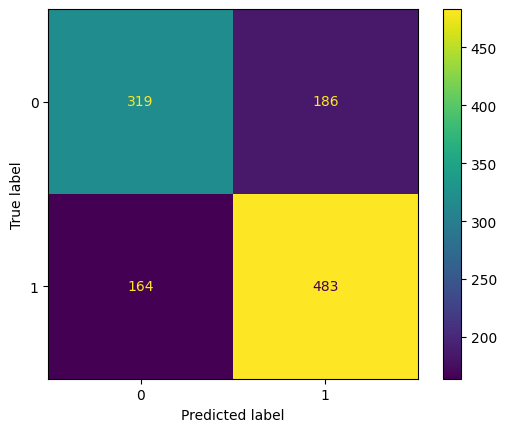

In [142]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay(cm).plot()       
plt.show()

In [143]:
print('{:<10} {:<10}'.format("Accuracy:", accuracy_score(y_test, y_pred)))
print('{:<10} {:<10}'.format("Precision:", precision_score(y_test, y_pred)))
print('{:<10} {:<10}'.format("Recall:", recall_score(y_test, y_pred)))
print('{:<10} {:<10}'.format("F1 Score:", f1_score(y_test, y_pred)))
print('{:<10} {:<10}'.format("ROC AUC Score:", roc_auc_score(y_test, y_pred)))

Accuracy:  0.6961805555555556
Precision: 0.7219730941704036
Recall:    0.7465224111282844
F1 Score:  0.7340425531914894
ROC AUC Score: 0.6891027897225581


## Comparison to VEGA model (k = 4 & Similarity Threshold = 0.7)

Accuracy:   0.7999305314345259
Precision:  0.8168631006346329
Recall:     0.8319482917820868
F1:         0.8243366880146387


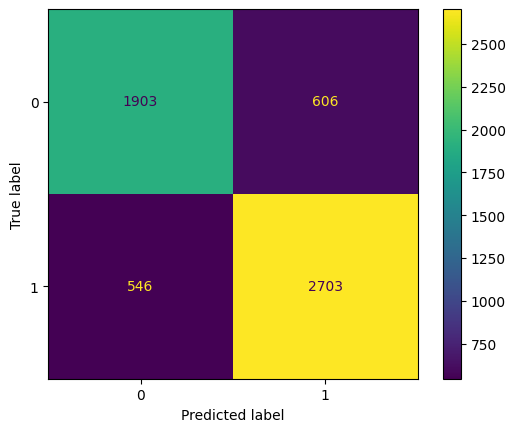

In [144]:
# VEGA model

y_clean = df['Experimental value'].astype(int)
y_vega_clean = df['Predicted value'].astype(int)

cm = confusion_matrix(y_clean, y_vega_clean)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

print('{:<10}  {:<15}'.format('Accuracy:', accuracy_score(y_clean, y_vega_clean)))
print('{:<10}  {:<15}'.format('Precision:', precision_score(y_clean, y_vega_clean)))
print('{:<10}  {:<15}'.format('Recall:', recall_score(y_clean, y_vega_clean)))
print('{:<10}  {:<15}'.format('F1:', f1_score(y_clean, y_vega_clean)))

# Finding the best k in kNN using K-Fold Cross Validation

In [145]:
num_ks = np.arange(1, 50, 1).astype(int)

train_missclass_rate = []
valid_missclass_rate = []

for i in tqdm(range(len(num_ks))):
  knn = KNeighborsClassifier(n_neighbors=num_ks[i])
  cv_dict = cross_validate(knn, X_train, y_train, cv=10, 
                                 scoring='accuracy', return_train_score=True)
  k_fold_train_score = cv_dict['train_score']
  k_fold_valid_score = cv_dict['test_score']

  train_missclass_rate.append(1-k_fold_train_score.mean())
  valid_missclass_rate.append(1-k_fold_valid_score.mean())

  0%|          | 0/49 [00:00<?, ?it/s]

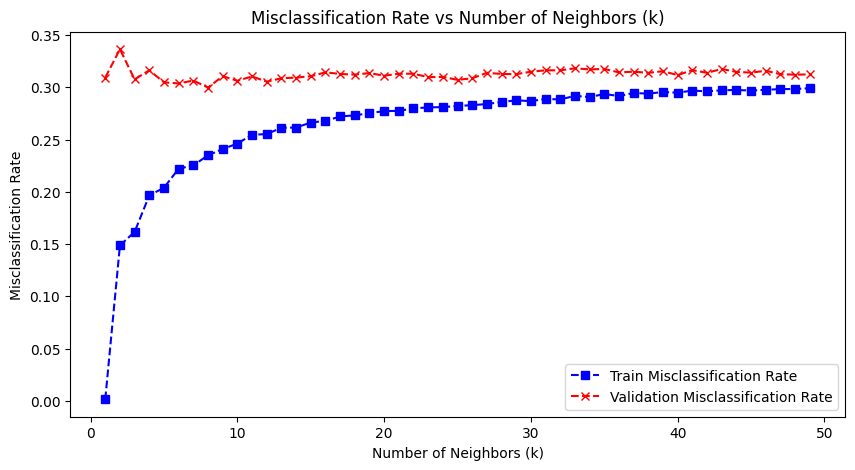

In [146]:
plt.figure(figsize=(10, 5))
plt.plot(num_ks, train_missclass_rate, 'bs--', label='Train Misclassification Rate')
plt.plot(num_ks, valid_missclass_rate, 'rx--', label='Validation Misclassification Rate')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Misclassification Rate')
plt.title('Misclassification Rate vs Number of Neighbors (k)')
plt.legend()
plt.show()

In [147]:
print(f"Best k: {num_ks[np.argmin(valid_missclass_rate)]}")

Best k: 8


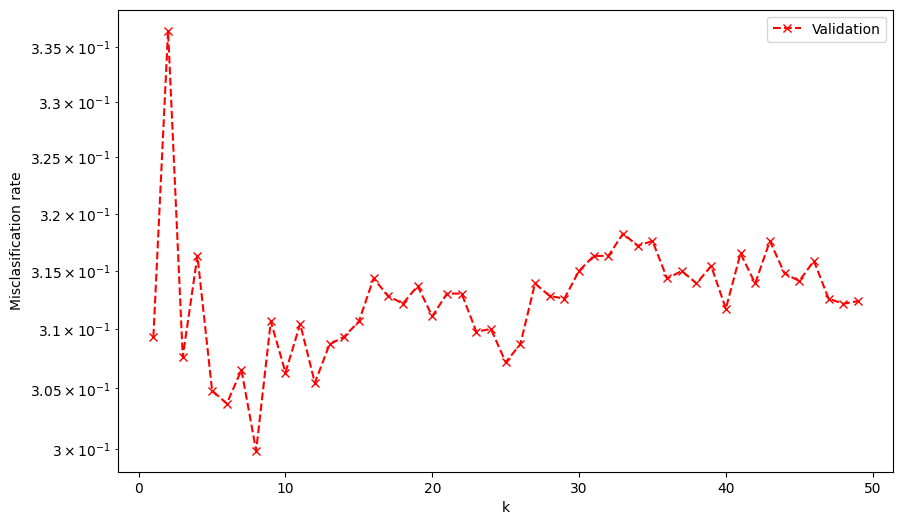

In [148]:
plt.figure(figsize=(10,6))
plt.plot(num_ks, valid_missclass_rate, 'rx--', label='Validation')
plt.yscale('log')
plt.xlabel('k')
plt.ylabel('Misclasification rate')
plt.legend()
plt.show()

## Final evaluation using k = 8

In [149]:
knn = KNeighborsClassifier(n_neighbors=8,
                           weights='distance')
knn.fit(X_train, y_train)

,n_neighbors,8
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [150]:
y_pred = knn.predict(X_test)

[[325 180]
 [155 492]]


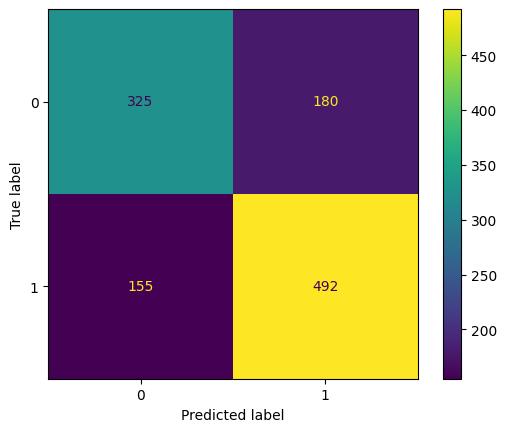

In [151]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay(cm).plot()       
plt.show()

In [152]:
print('{:<10} {:<10}'.format("Accuracy:", accuracy_score(y_test, y_pred)))
print('{:<10} {:<10}'.format("Precision:", precision_score(y_test, y_pred)))
print('{:<10} {:<10}'.format("Recall:", recall_score(y_test, y_pred)))
print('{:<10} {:<10}'.format("F1 Score:", f1_score(y_test, y_pred)))
print('{:<10} {:<10}'.format("ROC AUC Score:", roc_auc_score(y_test, y_pred)))

Accuracy:  0.7092013888888888
Precision: 0.7321428571428571
Recall:    0.7604327666151468
F1 Score:  0.7460197119029568
ROC AUC Score: 0.7019985615253951
